1. **Title**

Day 15 - Executive Hotel Booking EDA Report

This notebook presents an end-to-end exploratory data analysis of hotel booking data.
The analysis covers data quality, cleaning, booking patterns, cancellations,
revenue, customer behavior, relationships between variables, and business insights.

2. **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

3. **Load Dataset**

In [2]:
df = pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset (1).csv")
df.head()

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


4. **Dataset Overview**

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 25180
Columns: 35


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

In [5]:
df.describe()

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Agent_ID,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
count,25180.000000,25180.000000,25180.000000,25180.000000,25059.000000,25180.000000,25180.000000,25180.000000,25180.000000,25180.000000,24876.000000,4451.000000,25180.000000,25180.000000,25098.000000,25180.000000,25180.000000,25016.000000,25180.000000,25180.000000
mean,182.200556,1.240429,2.451072,2.198967,0.372122,0.043050,0.172597,0.038642,1.117037,0.601191,89.698866,1059.135700,1.561438,3.693090,140.628124,0.228753,1.097458,3.854402,0.721763,535.495478
std,105.604452,1.063802,2.031003,0.662379,0.657811,0.225057,0.377906,0.251403,2.829046,0.894293,51.731839,34.270543,4.459498,2.085623,47.808034,0.530060,1.047671,0.405110,0.448140,389.700003
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1001.000000,0.000000,1.000000,30.800000,0.000000,0.000000,0.300000,0.000000,31.820000
25%,91.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1029.000000,0.000000,2.000000,105.620000,0.000000,0.000000,3.590000,0.000000,230.540000
50%,182.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89.000000,1059.000000,0.000000,4.000000,134.425000,0.000000,1.000000,3.860000,1.000000,448.735000
75%,273.000000,2.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,135.000000,1088.000000,1.000000,5.000000,169.097500,0.000000,2.000000,4.130000,1.000000,737.577500
max,920.000000,3.000000,13.000000,7.000000,6.000000,2.000000,1.000000,3.000000,12.000000,4.000000,179.000000,1119.000000,180.000000,45.000000,710.500000,3.000000,5.000000,5.900000,1.000000,3256.020000


5. **Data Quality Check**

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
Company_ID,20729
Country,466
Agent_ID,304
Meal_Type,245
Satisfaction_Score,164
Children,121
Hotel_Location,106
ADR,82


In [7]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 180


6. **Remove Duplicate Records**

In [8]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])
print("Duplicates remaining:", df.duplicated().sum())

Rows after removing duplicates: 25000
Duplicates remaining: 0


7. **Check Data Types**

In [10]:
df.dtypes

,0
Booking_ID,object
Hotel_Type,object
Hotel_Location,object
Booking_Date,object
Arrival_Date,object
Lead_Time_Days,int64
Weekend_Nights,int64
Weekday_Nights,int64
Adults,int64
Children,float64


In [11]:
date_columns = [
    "Booking_Date",
    "Arrival_Date",
    "Reservation_Status_Date"
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], errors="coerce")

In [12]:
df[date_columns].dtypes

,0
Booking_Date,datetime64[ns]
Arrival_Date,datetime64[ns]
Reservation_Status_Date,datetime64[ns]


8. **Check Categorical Values**

In [13]:
print(df["Hotel_Type"].unique())
print(df["Market_Segment"].unique())
print(df["Deposit_Type"].unique())
print(df["Customer_Type"].unique())
print(df["Meal_Type"].unique())

['City Hotel' 'Resort Hotel' 'CITY HOTEL' 'city hotel' 'City hotel']
['Direct' 'Groups' 'Online TA' 'Offline TA/TO' 'Online TA ' 'Corporate'
 'online ta' 'ONLINE TA']
['Non Refund' 'No Deposit' 'Refundable']
['Contract' 'Transient' 'Group' 'Transient-Party']
['HB' 'Undefined' 'FB' 'SC' 'BB' nan 'BB ' 'bb' ' B&B ' 'Unknown']


In [14]:
categorical_columns = [
    "Hotel_Type",
    "Hotel_Location",
    "Market_Segment",
    "Distribution_Channel",
    "Deposit_Type",
    "Customer_Type",
    "Meal_Type",
    "Reservation_Status"
]

for column in categorical_columns:
    df[column] = df[column].astype("string").str.strip()

9. **Handle Missing Values**

In [16]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Hotel_Location,105
Children,120
Country,462
Agent_ID,300
Company_ID,20585
Meal_Type,239
ADR,80
Satisfaction_Score,160


In [17]:
df["Children"] = df["Children"].fillna(df["Children"].median())
df["ADR"] = df["ADR"].fillna(df["ADR"].median())
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(
    df["Satisfaction_Score"].median()
)

In [18]:
df["Country"] = df["Country"].fillna("Unknown")
df["Meal_Type"] = df["Meal_Type"].fillna("Unknown")
df["Hotel_Location"] = df["Hotel_Location"].fillna("Unknown")

In [19]:
df["Agent_ID"] = df["Agent_ID"].fillna(0)
df["Company_ID"] = df["Company_ID"].fillna(0)

In [20]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


10. **Create Useful Features**

In [21]:
df["Total_Guests"] = (
    df["Adults"] + df["Children"] + df["Babies"]
)

In [22]:
df["Arrival_Month"] = df["Arrival_Date"].dt.month_name()

In [23]:
df["Arrival_Day"] = df["Arrival_Date"].dt.day_name()

In [24]:
df[[
    "Arrival_Date",
    "Arrival_Month",
    "Arrival_Day",
    "Total_Guests",
    "Total_Nights"
]].head()

,Arrival_Date,Arrival_Month,Arrival_Day,Total_Guests,Total_Nights
0,2025-07-04,July,Friday,2.0,4
1,2025-02-08,February,Saturday,4.0,3
2,2024-06-20,June,Thursday,4.0,2
3,2024-04-07,April,Sunday,2.0,2
4,2025-05-30,May,Friday,4.0,3


11. **Outlier Detection**

In [25]:
numeric_columns = [
    "Lead_Time_Days",
    "Total_Nights",
    "ADR",
    "Estimated_Revenue",
    "Total_Guests"
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower) | (df[column] > upper)).sum()

    print(column, ":", outliers, "outliers")

Lead_Time_Days : 2 outliers
Total_Nights : 136 outliers
ADR : 360 outliers
Estimated_Revenue : 652 outliers
Total_Guests : 1082 outliers


12. **Visualize Outliers**

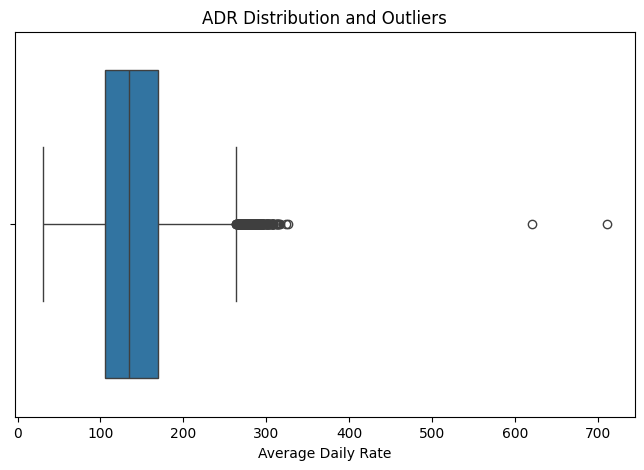

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="ADR")

plt.title("ADR Distribution and Outliers")
plt.xlabel("Average Daily Rate")

plt.show()

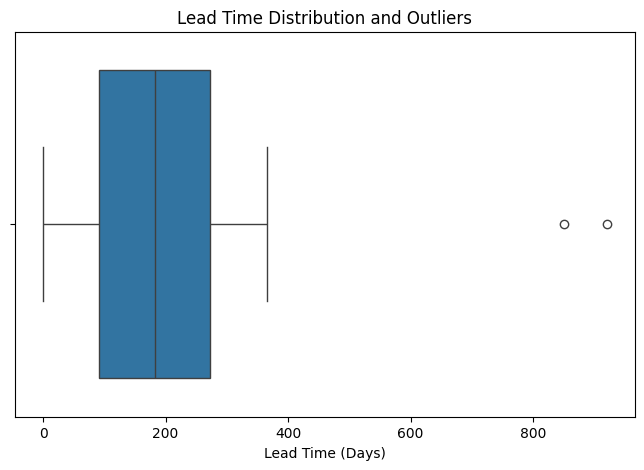

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Lead_Time_Days")

plt.title("Lead Time Distribution and Outliers")
plt.xlabel("Lead Time (Days)")

plt.show()

13. **Univariate Analysis — Hotel Type**

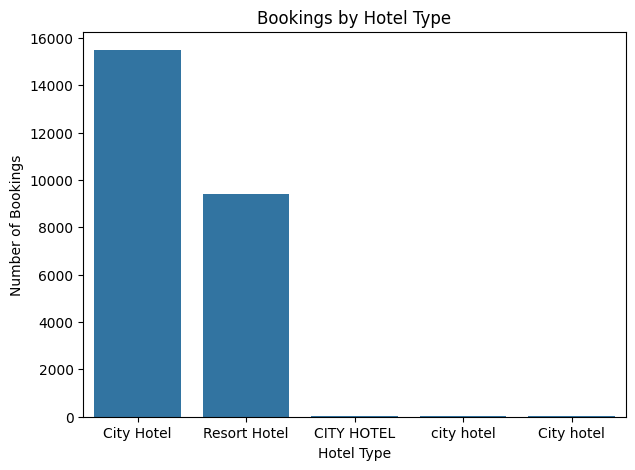

In [28]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Hotel_Type")

plt.title("Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.show()

#Interpretation:

The chart shows how bookings are distributed between the different hotel types and helps identify which type contributes more to the booking volume.


14. **Cancellation Analysis**

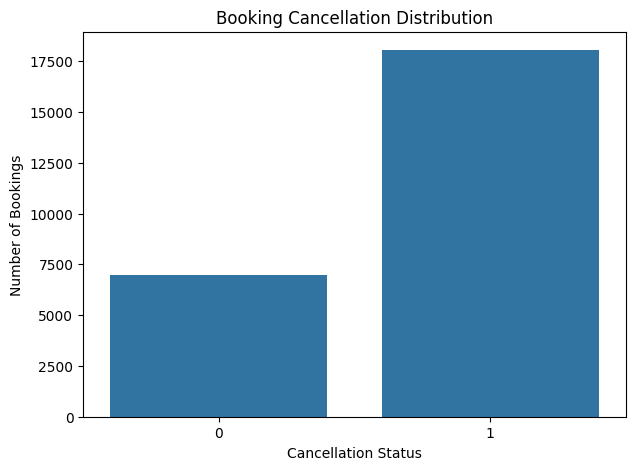

In [29]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Is_Canceled")

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")

plt.show()

In [30]:
print("Cancellation Rate:",
      round(df["Is_Canceled"].mean() * 100, 2), "%")

Cancellation Rate: 72.18 %


15. **Lead Time Distribution**

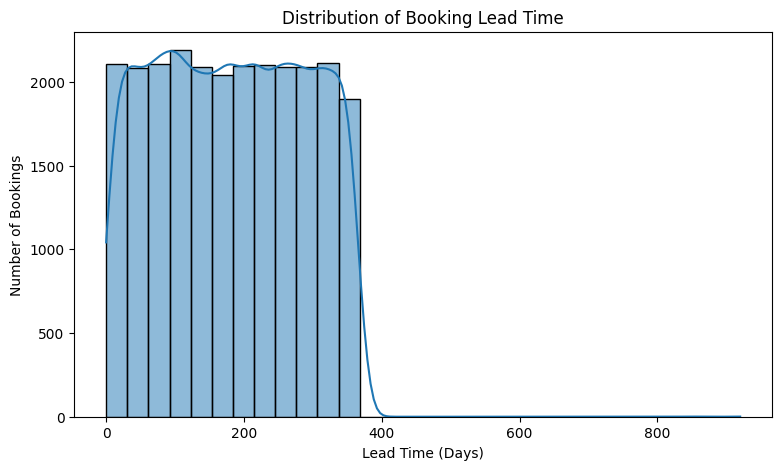

In [31]:
plt.figure(figsize=(9, 5))

sns.histplot(df["Lead_Time_Days"], bins=30, kde=True)

plt.title("Distribution of Booking Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")

plt.show()

16. **Revenue Distribution**

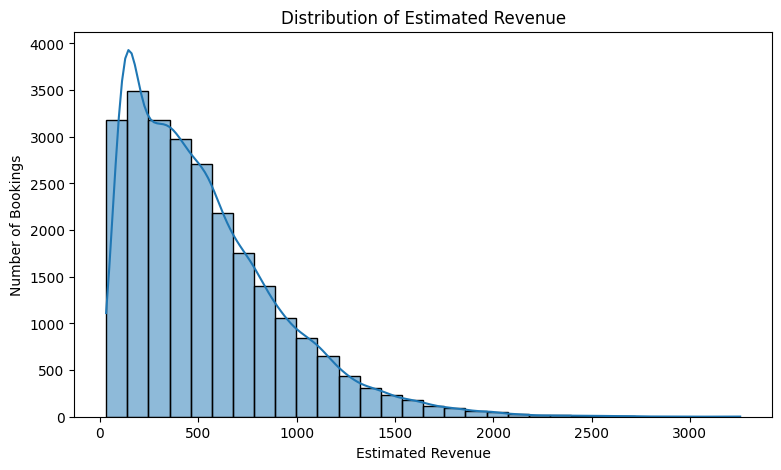

In [32]:
plt.figure(figsize=(9, 5))

sns.histplot(df["Estimated_Revenue"], bins=30, kde=True)

plt.title("Distribution of Estimated Revenue")
plt.xlabel("Estimated Revenue")
plt.ylabel("Number of Bookings")

plt.show()

17. **Revenue by Hotel Type**

In [33]:
hotel_revenue = df.groupby("Hotel_Type")["Estimated_Revenue"].agg(
    ["sum", "mean"]
)

hotel_revenue

,sum,mean
Hotel_Type,,
CITY HOTEL,25029.50,568.852273
City Hotel,5951244.46,384.174324
City hotel,18463.59,559.502727
Resort Hotel,7365874.95,784.521775
city hotel,23586.95,548.533721


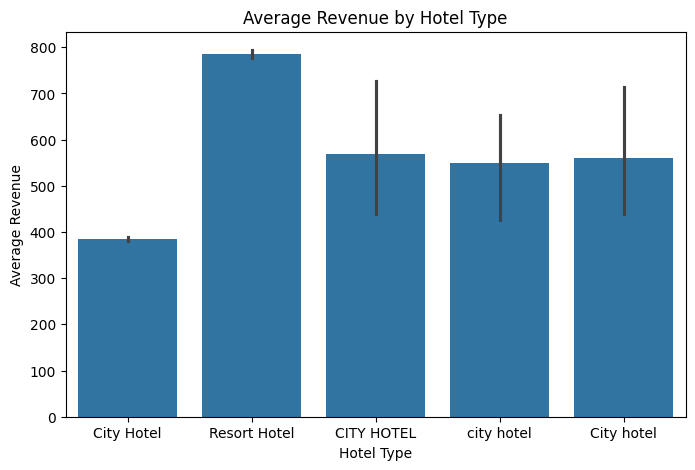

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Hotel_Type",
    y="Estimated_Revenue",
    estimator="mean"
)

plt.title("Average Revenue by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Revenue")

plt.show()

18. **Market Segment Analysis**

In [35]:
market_analysis = df.groupby("Market_Segment").agg({
    "Booking_ID": "count",
    "Estimated_Revenue": "sum",
    "ADR": "mean",
    "Is_Canceled": "mean"
})

market_analysis.sort_values(
    "Estimated_Revenue",
    ascending=False
)

,Booking_ID,Estimated_Revenue,ADR,Is_Canceled
Market_Segment,,,,
Online TA,10750,5882172.78,143.265365,0.751721
Offline TA/TO,5440,2944293.73,142.393578,0.704228
Direct,3808,2098049.99,143.249165,0.712185
Corporate,2990,1492611.61,134.156130,0.674916
Groups,1910,917235.87,125.317050,0.697906
ONLINE TA,52,25876.48,135.690000,0.615385
online ta,50,23958.99,138.973700,0.740000


19. **Deposit Type vs Cancellation**

In [36]:
deposit_analysis = df.groupby("Deposit_Type").agg({
    "Booking_ID": "count",
    "Is_Canceled": "mean",
    "Estimated_Revenue": "sum"
})

deposit_analysis

,Booking_ID,Is_Canceled,Estimated_Revenue
Deposit_Type,,,
No Deposit,12144,0.515893,6575759.72
Non Refund,12401,0.929764,6578303.03
Refundable,455,0.547253,230136.70


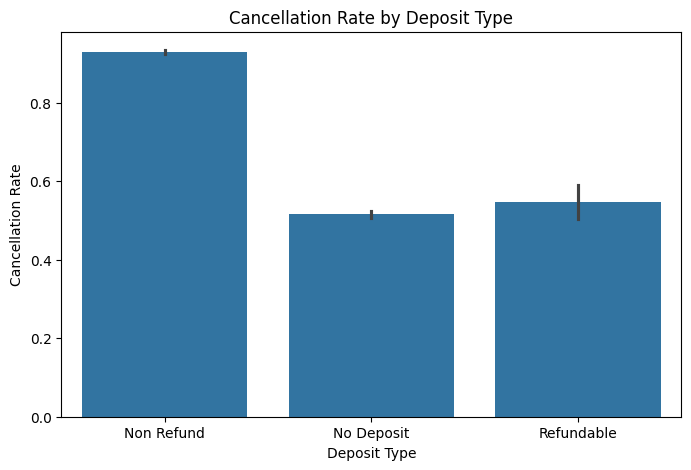

In [37]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Deposit_Type",
    y="Is_Canceled"
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate")

plt.show()

20. **Customer Type Analysis**

In [38]:
customer_analysis = df.groupby("Customer_Type").agg({
    "Booking_ID": "count",
    "Estimated_Revenue": "sum",
    "ADR": "mean",
    "Is_Canceled": "mean"
})

customer_analysis

,Booking_ID,Estimated_Revenue,ADR,Is_Canceled
Customer_Type,,,,
Contract,6403,3461023.69,140.720939,0.719506
Group,6283,3355007.34,140.608356,0.727041
Transient,6027,3251091.77,141.162575,0.723411
Transient-Party,6287,3317076.65,139.882011,0.717194


21. **Hotel Location Analysis**

In [39]:
location_analysis = df.groupby("Hotel_Location").agg({
    "Booking_ID": "count",
    "Estimated_Revenue": "sum",
    "ADR": "mean",
    "Is_Canceled": "mean"
})

location_analysis.sort_values(
    "Estimated_Revenue",
    ascending=False
)

,Booking_ID,Estimated_Revenue,ADR,Is_Canceled
Hotel_Location,,,,
Goa,1957,1568006.15,174.230613,0.680123
Bali,1882,1494345.71,173.716445,0.706695
Algarve,1902,1471887.02,174.380691,0.711356
Maldives,1845,1435469.77,172.877043,0.714905
Phuket,1813,1403754.61,172.348919,0.702703
Dubai,3148,1216911.07,121.068766,0.735705
London,3106,1207466.30,121.533435,0.739858
Lisbon,3148,1198314.63,120.623391,0.731576
Barcelona,3061,1175082.43,120.343401,0.734401


22. **Monthly Revenue**

In [40]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_revenue = df.groupby(
    "Arrival_Month"
)["Estimated_Revenue"].sum().reindex(month_order)

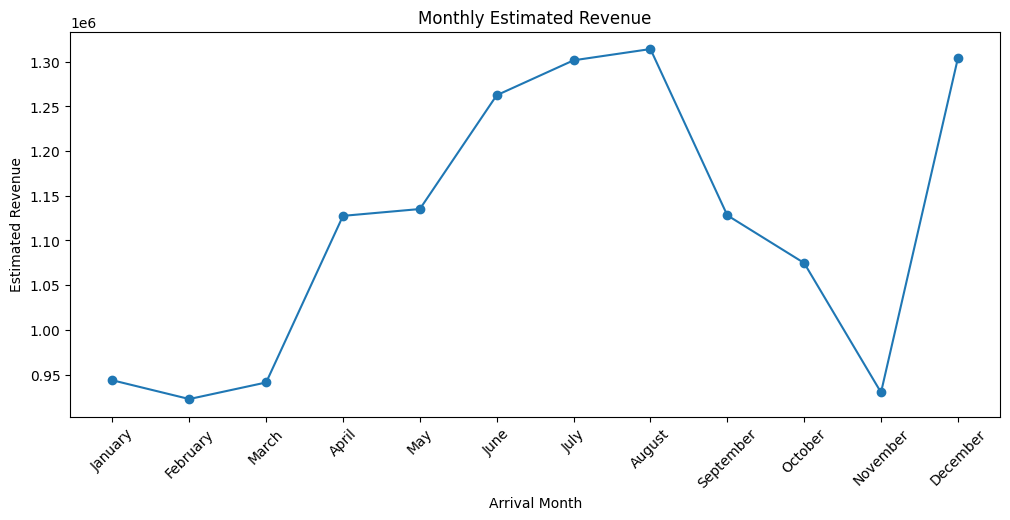

In [41]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Estimated Revenue")
plt.xlabel("Arrival Month")
plt.ylabel("Estimated Revenue")
plt.xticks(rotation=45)

plt.show()

23. **Lead Time vs Cancellation**

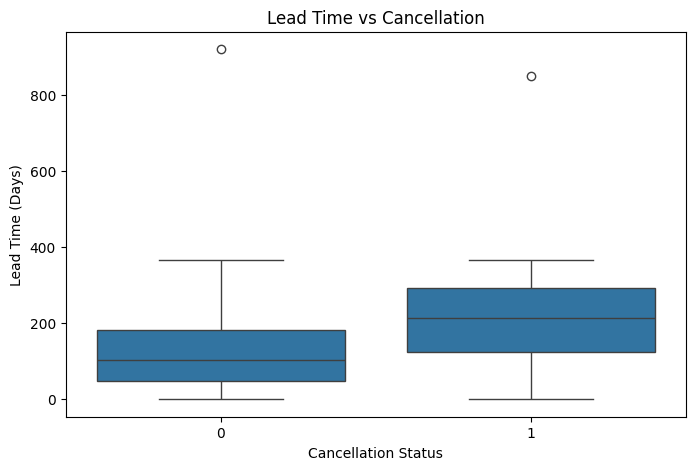

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Is_Canceled",
    y="Lead_Time_Days"
)

plt.title("Lead Time vs Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Lead Time (Days)")

plt.show()

24. **ADR vs Revenue**

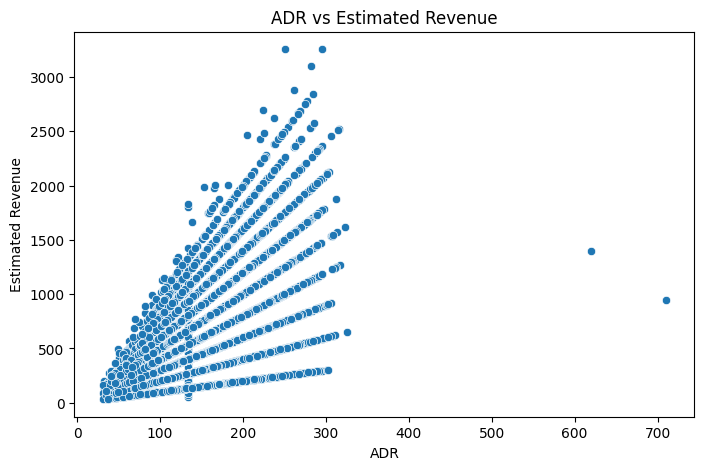

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="ADR",
    y="Estimated_Revenue"
)

plt.title("ADR vs Estimated Revenue")
plt.xlabel("ADR")
plt.ylabel("Estimated Revenue")

plt.show()

25. **Correlation Heatmap**

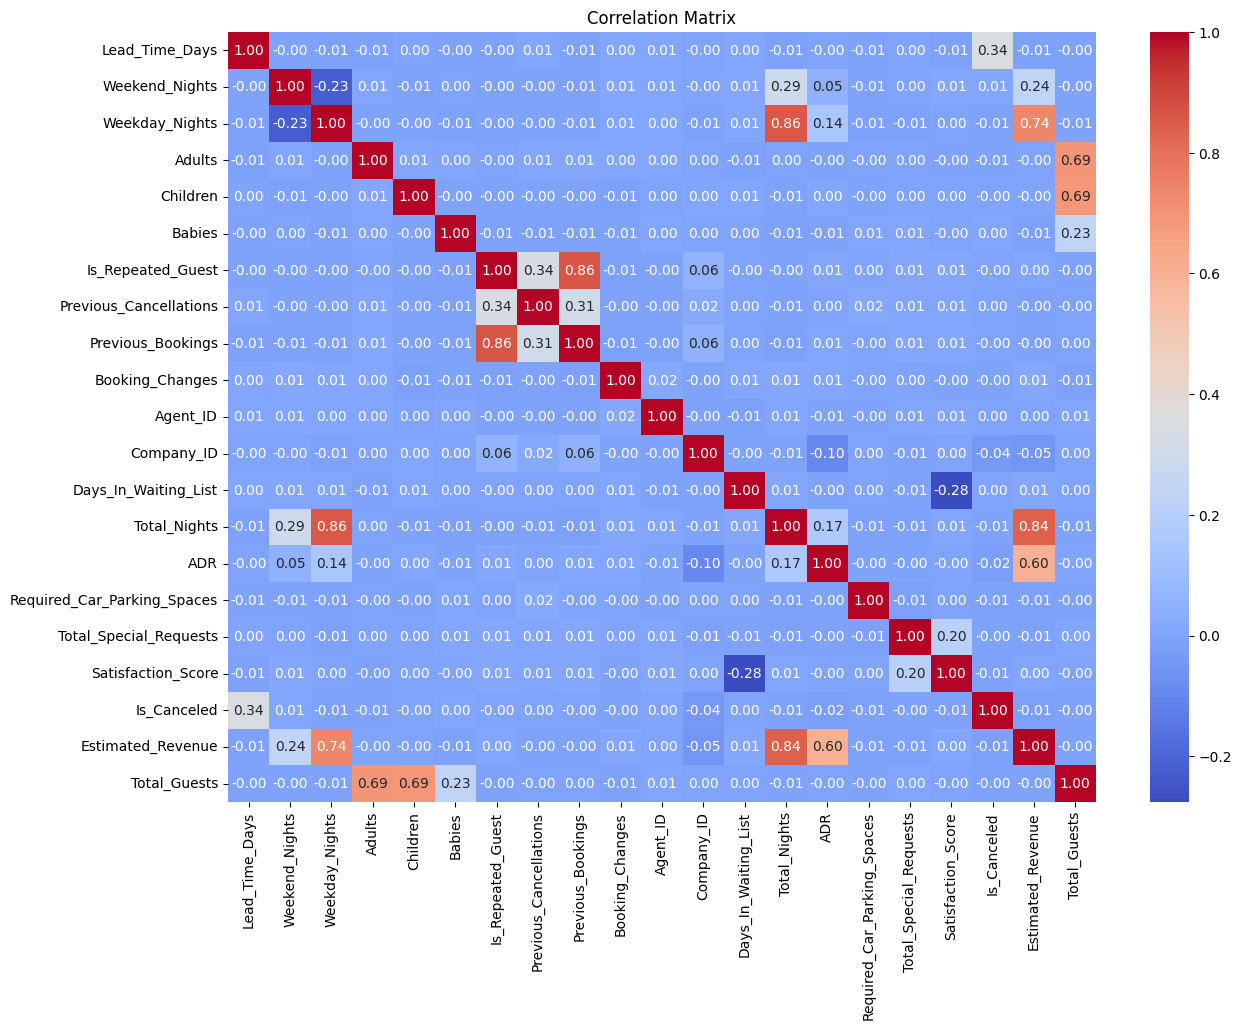

In [44]:
numeric_data = df.select_dtypes(include="number")

correlation = numeric_data.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

26. **Revenue Correlations**

In [45]:
correlation["Estimated_Revenue"].sort_values(
    ascending=False
)

,Estimated_Revenue
Estimated_Revenue,1.000000
Total_Nights,0.837965
Weekday_Nights,0.736105
ADR,0.602987
Weekend_Nights,0.237120
Booking_Changes,0.013054
Days_In_Waiting_List,0.010958
Satisfaction_Score,0.004738
Is_Repeated_Guest,0.003638
Agent_ID,0.001531


27. **Customer Satisfaction vs Revenue**

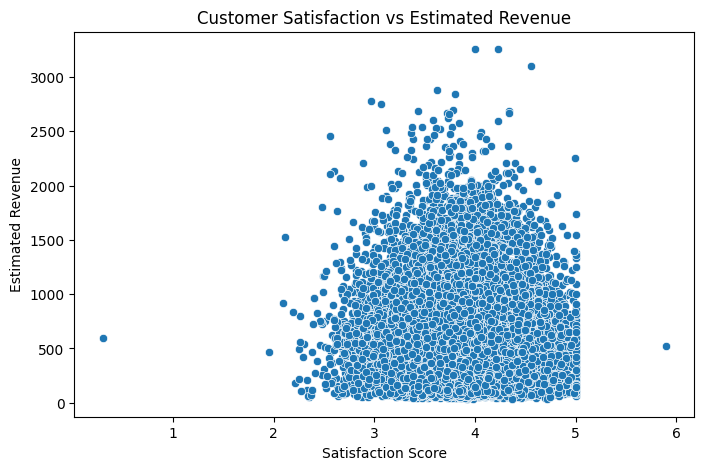

In [46]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Satisfaction_Score",
    y="Estimated_Revenue"
)

plt.title("Customer Satisfaction vs Estimated Revenue")
plt.xlabel("Satisfaction Score")
plt.ylabel("Estimated Revenue")

plt.show()

28. **Final Data Quality Check**

In [47]:
print("Final rows:", df.shape[0])
print("Final columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final rows: 25000
Final columns: 38
Missing values: 0
Duplicate rows: 0


29. **Key Business Insights**


- The analysis shows a clear difference in booking and revenue performance between City Hotels and Resort Hotels, indicating that the two hotel types have different business patterns.

- Cancellations represent a significant concern, and the relationship between deposit type and cancellation behavior suggests that payment policies can influence booking reliability.

- Online Travel Agencies contribute a major share of bookings and revenue, making this channel important for the hotel's overall performance.

- Longer stays and higher room rates contribute strongly to estimated revenue, making both pricing and length of stay important revenue drivers.

- Booking lead time is also connected with cancellation behavior, which means reservations made far in advance may require closer monitoring.


30. **Management Recommendations**

- Use different pricing and promotional strategies for City Hotels and Resort Hotels based on their booking patterns.

- Introduce stronger cancellation controls or partial deposits for bookings that have a higher cancellation risk.

- Continue using Online Travel Agencies while regularly reviewing their revenue contribution and overall profitability.

- Encourage longer stays through packages, discounts, and value-added offers.

- Monitor long-lead bookings more closely and use reminders or flexible rebooking options to reduce cancellations.

- Adjust pricing according to seasonal demand and monthly revenue patterns.

- Track ADR, cancellation rates, and revenue together when evaluating pricing decisions.